# **PARTE 1 | DATASET**

In [ ]:
# Importacion dataset original desde Kaggle:

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "entrenamiento.csv"

df_original = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "alejandroczernikier/properati-argentina-dataset",
  file_path,
)

/tmp/ipython-input-3594693475.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_original = kagglehub.load_dataset(


100%|██████████| 862M/862M [00:11<00:00, 77.6MB/s]


In [ ]:
df_original.head()

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
0,556713,Propiedad,2019-11-29,9999-12-31,2019-11-29,-58.442399,-34.573623,Argentina,Capital Federal,Colegiales,...,2.0,NaN,NaN,USD,NaN,"Departamento en Venta en Belgrano, Capital fed...","Sup total por escritura: 96,47 m2 (cubiertos: ...",Departamento,Venta,259000.0
1,192912,Propiedad,2020-06-05,2020-06-08,2020-06-05,-58.430493,-34.606620,Argentina,Capital Federal,Almagro,...,2.0,77.0,67.0,USD,NaN,Departamento de 3 ambientes en Venta en Almagro,Excelente departamento de tres ambientes ampli...,Departamento,Venta,235500.0
2,238224,Propiedad,2020-07-01,9999-12-31,2020-07-01,-58.491760,-34.574123,Argentina,Capital Federal,Villa Urquiza,...,1.0,60.0,55.0,USD,NaN,Andonaegui 2600 4° - - Departamento en Venta,Excelente 3 ambientes al frente con balcón. Vi...,Departamento,Venta,175000.0
3,257134,Propiedad,2019-08-17,9999-12-31,2019-08-17,-58.420737,-34.631770,Argentina,Capital Federal,Boedo,...,1.0,74.0,47.0,USD,NaN,PH Venta Boedo 2 amb Patio,Corredor Responsable: MARCELO TRUJILLO - CPI ...,PH,Venta,140000.0
4,521738,Propiedad,2019-08-05,2019-08-31,2019-08-05,-58.429983,-34.607225,Argentina,Capital Federal,Almagro,...,1.0,66.0,64.0,USD,NaN,Venta 3 Ambientes - Almagro - Balcón - Ameniti...,Corredor Responsable: Marcelo Trujillo - CUCIC...,Departamento,Venta,173000.0


In [ ]:
df_original.tail()

,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,currency,price_period,title,description,property_type,operation_type,price
992187,999996,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.575169,-38.042062,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,...,5.0,NaN,NaN,USD,NaN,Venta en Bloque,Venta en bloque de esta importante propiedad. ...,Casa,Venta,190000.0
992188,999997,Propiedad,2020-01-09,2020-04-27,2020-01-09,-68.860929,-32.953935,Argentina,Mendoza,Cuadro Benegas,...,5.0,NaN,NaN,USD,NaN,PALMARES SEGUNDA ETAPA,RIVEROS PROPIEDADES VENDE: Casa Desarrollada E...,Casa,Venta,520000.0
992189,999998,Propiedad,2020-01-09,2020-04-27,2020-01-09,-57.963191,-34.920051,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,...,5.0,NaN,NaN,ARS,NaN,"Departamento en Alquiler, 44mts, 0 dormitorios...",16 N&deg;706 y 46 se alquila monoambiente e...,Departamento,Alquiler,12000.0
992190,999999,Propiedad,2020-01-09,2020-04-28,2020-01-09,-57.549815,-38.020436,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,...,5.0,NaN,NaN,USD,NaN,IMPORTANTE RESIDENCIA EN DIVINO ROSTRO,En importante ubicación del tradicional Barrio...,Casa,Venta,550000.0
992191,1000000,Propiedad,2020-01-09,2020-04-28,2020-01-09,NaN,NaN,Argentina,Capital Federal,NaN,...,5.0,NaN,NaN,ARS,NaN,BARBARO ALQUILA LOCALES EN SAN MARTIN CENTRO,"Barbaro Alquila Galpon , la superficie cubier...",Otro,Venta,800000.0


In [ ]:
# Shape del Dataset original:
df_original.shape

(992192, 25)

In [ ]:
# Nombres de columnas:
df_original.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price'],
      dtype='object')

In [ ]:
# Nuevo df con columnas especificas:
df_reducido=df_original[['l2','bedrooms','bathrooms','currency','property_type','operation_type','surface_covered','price']]


In [ ]:
# Rename de las columnas:
df_reducido = df_reducido.rename(columns={'l2': 'Localidad','bedrooms':'Dormitorios','bathrooms':'Baños','currency':'Moneda','property_type':'Tipo propiedad','operation_type':'Tipo operacion','surface_covered':'Superficie_cubierta','price':'Precio'})

In [ ]:
# Control tipo de datos:
df_reducido.dtypes

,0
Localidad,object
Dormitorios,float64
Baños,float64
Moneda,object
Tipo propiedad,object
Tipo operacion,object
Superficie_cubierta,float64
Precio,float64


In [ ]:
# Correccion tipo de datos:

df_reducido=df_reducido.astype({'Dormitorios': 'Int64', 'Baños': 'Int64', 'Superficie_cubierta': 'Int64', 'Precio': 'Int64'})

In [ ]:
# Shape nuevo df:
df_reducido.shape

(992192, 8)

In [ ]:
# Conteo registros duplicados completos:"
print(df_reducido.duplicated().sum())

628198


In [ ]:
# Eliminacion duplicados y nuevo Shape:
df_sinduplicados = df_reducido.drop_duplicates()
df_sinduplicados.shape

(363994, 8)

In [ ]:
# Conteo valores nulos por columna"
print(df_sinduplicados.isnull().sum())


Localidad                   0
Dormitorios            176969
Baños                   61521
Moneda                  16866
Tipo propiedad              0
Tipo operacion              0
Superficie_cubierta     95027
Precio                  15423
dtype: int64


In [ ]:
# Se decide eliminar los registros que no tienen numero de habitaciones, numero de baños, una moneda especifica o precio ya que son claves para el analisis.
df_sinduplicados = df_sinduplicados.dropna(subset=['Dormitorios', 'Baños', 'Moneda', 'Superficie_cubierta','Precio'])
df_sinduplicados.shape


(131121, 8)

In [ ]:
df_sinduplicados.describe()

,Dormitorios,Baños,Superficie_cubierta,Precio
count,131121.0,131121.0,131121.0,131121.0
mean,2.443095,1.9509,178.623798,355909.310805
std,2.788032,1.183699,3270.562449,1417204.611797
min,-3.0,1.0,-152.0,50.0
25%,2.0,1.0,58.0,50000.0
50%,2.0,2.0,92.0,133000.0
75%,3.0,2.0,175.0,270000.0
max,900.0,20.0,1000000.0,62115000.0


In [ ]:
# Filtrado de los registros por presencia de valores negativos en cantidad y posibles outliers:
df_sinduplicados_sin_errores=df_sinduplicados[(df_sinduplicados['Dormitorios']>=1) & (df_sinduplicados['Dormitorios']<10) & (df_sinduplicados['Superficie_cubierta']>50) & (df_sinduplicados['Superficie_cubierta']<200)& (df_sinduplicados['Precio']<500000)]
df_sinduplicados_sin_errores.describe()

,Dormitorios,Baños,Superficie_cubierta,Precio
count,73602.0,73602.0,73602.0,73602.0
mean,2.371158,1.723173,100.837708,150260.969851
std,0.833422,0.783509,39.590978,114334.864756
min,1.0,1.0,51.0,50.0
25%,2.0,1.0,68.0,51000.0
50%,2.0,2.0,90.0,134000.0
75%,3.0,2.0,128.0,220000.0
max,9.0,14.0,199.0,499999.0


In [ ]:
# se seleccionan propiedades unicamente en VENTA
dataset_ventas = df_sinduplicados_sin_errores[df_sinduplicados_sin_errores['Tipo operacion'] =='Venta']
dataset_ventas

,Localidad,Dormitorios,Baños,Moneda,Tipo propiedad,Tipo operacion,Superficie_cubierta,Precio
1,Capital Federal,2,2,USD,Departamento,Venta,67,235500
4,Capital Federal,2,1,USD,Departamento,Venta,64,173000
5,Capital Federal,2,1,USD,PH,Venta,55,155000
9,Capital Federal,2,2,USD,Departamento,Venta,80,240000
12,Capital Federal,2,2,USD,Departamento,Venta,76,190000
...,...,...,...,...,...,...,...,...
991769,Capital Federal,3,3,USD,Departamento,Venta,87,340000
991929,Capital Federal,5,4,USD,PH,Venta,158,159000
991951,Bs.As. G.B.A. Zona Norte,3,4,USD,Casa,Venta,173,349000
991964,Bs.As. G.B.A. Zona Norte,3,4,ARS,Casa,Venta,166,420000


In [ ]:
# se seleccionan propiedades unicamente en USD
dataset_ventas_uss=dataset_ventas[dataset_ventas['Moneda']=='USD']
dataset_ventas_uss

,Localidad,Dormitorios,Baños,Moneda,Tipo propiedad,Tipo operacion,Superficie_cubierta,Precio
1,Capital Federal,2,2,USD,Departamento,Venta,67,235500
4,Capital Federal,2,1,USD,Departamento,Venta,64,173000
5,Capital Federal,2,1,USD,PH,Venta,55,155000
9,Capital Federal,2,2,USD,Departamento,Venta,80,240000
12,Capital Federal,2,2,USD,Departamento,Venta,76,190000
...,...,...,...,...,...,...,...,...
991747,Neuquén,4,3,USD,Casa,Venta,186,290000
991769,Capital Federal,3,3,USD,Departamento,Venta,87,340000
991929,Capital Federal,5,4,USD,PH,Venta,158,159000
991951,Bs.As. G.B.A. Zona Norte,3,4,USD,Casa,Venta,173,349000


# **PARTE 2 | NUMPY Y PANDAS**

In [ ]:
# Creacion array desde columna precio del Dataset.
import numpy as np
array_precio = np.array(dataset_ventas_uss['Precio'])


In [ ]:
# Promedio
promedio = np.mean(array_precio)
print(promedio)

194241.01369888545


In [ ]:
# Mediana
mediana = np.median(array_precio)
print(mediana)

172000.0


In [ ]:
# Desviacion estandar.
des_estandar = np.std(array_precio)
print(des_estandar)

101221.90190241141


In [ ]:
# Nueva columna Precio por metro, en base al precio sobre la superficie de la propiedad.
dataset_ventas_uss['Precio_por_metro']=dataset_ventas_uss['Precio']/dataset_ventas_uss['Superficie_cubierta']
dataset_ventas_uss

/tmp/ipython-input-2068829207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_ventas_uss['Precio_por_metro']=dataset_ventas_uss['Precio']/dataset_ventas_uss['Superficie_cubierta']


,Localidad,Dormitorios,Baños,Moneda,Tipo propiedad,Tipo operacion,Superficie_cubierta,Precio,Precio_por_metro
1,Capital Federal,2,2,USD,Departamento,Venta,67,235500,3514.925373
4,Capital Federal,2,1,USD,Departamento,Venta,64,173000,2703.125
5,Capital Federal,2,1,USD,PH,Venta,55,155000,2818.181818
9,Capital Federal,2,2,USD,Departamento,Venta,80,240000,3000.0
12,Capital Federal,2,2,USD,Departamento,Venta,76,190000,2500.0
...,...,...,...,...,...,...,...,...,...
991747,Neuquén,4,3,USD,Casa,Venta,186,290000,1559.139785
991769,Capital Federal,3,3,USD,Departamento,Venta,87,340000,3908.045977
991929,Capital Federal,5,4,USD,PH,Venta,158,159000,1006.329114
991951,Bs.As. G.B.A. Zona Norte,3,4,USD,Casa,Venta,173,349000,2017.34104


In [ ]:
# Filtrado propiedades cuyo precio es mayor al promedio
dataset_ventas_uss_caros=dataset_ventas_uss[dataset_ventas['Precio']>promedio]
dataset_ventas_uss_caros

/tmp/ipython-input-329041504.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataset_ventas_uss_caros=dataset_ventas_uss[dataset_ventas['Precio']>promedio]


,Localidad,Dormitorios,Baños,Moneda,Tipo propiedad,Tipo operacion,Superficie_cubierta,Precio,Precio_por_metro
1,Capital Federal,2,2,USD,Departamento,Venta,67,235500,3514.925373
9,Capital Federal,2,2,USD,Departamento,Venta,80,240000,3000.0
15,Capital Federal,2,2,USD,PH,Venta,52,208000,4000.0
16,Capital Federal,2,3,USD,Departamento,Venta,85,498000,5858.823529
17,Capital Federal,2,2,USD,Departamento,Venta,61,258000,4229.508197
...,...,...,...,...,...,...,...,...,...
991435,Capital Federal,4,3,USD,Departamento,Venta,107,205000,1915.88785
991747,Neuquén,4,3,USD,Casa,Venta,186,290000,1559.139785
991769,Capital Federal,3,3,USD,Departamento,Venta,87,340000,3908.045977
991951,Bs.As. G.B.A. Zona Norte,3,4,USD,Casa,Venta,173,349000,2017.34104


In [ ]:
# Ordenacion Multiple por mayor superficie y mayor precio.
dataset_ventas_uss_caros_ordenado = dataset_ventas_uss_caros.sort_values(by=['Precio','Superficie_cubierta'], ascending=False)
dataset_ventas_uss_caros_ordenado

,Localidad,Dormitorios,Baños,Moneda,Tipo propiedad,Tipo operacion,Superficie_cubierta,Precio,Precio_por_metro
427796,Córdoba,3,1,USD,Casa,Venta,120,499999,4166.658333
687758,Capital Federal,1,2,USD,Departamento,Venta,75,499999,6666.653333
37567,Capital Federal,4,3,USD,Departamento,Venta,193,499900,2590.15544
978531,Capital Federal,1,2,USD,Departamento,Venta,62,499800,8061.290323
338531,Bs.As. G.B.A. Zona Norte,4,4,USD,Casa,Venta,185,499000,2697.297297
...,...,...,...,...,...,...,...,...,...
498425,Capital Federal,2,1,USD,Departamento,Venta,52,194500,3740.384615
495467,Bs.As. G.B.A. Zona Norte,2,2,USD,Departamento,Venta,69,194481,2818.565217
825731,Montevideo,2,1,USD,Departamento,Venta,59,194420,3295.254237
302176,Capital Federal,1,2,USD,Departamento,Venta,53,194400,3667.924528


In [ ]:

# Promedio de precios agrupados por Localidades.
dataset_ventas_uss_caros_agrupados = dataset_ventas_uss_caros.groupby('Localidad')['Precio'].mean().astype(int).sort_values(ascending=False)
dataset_ventas_uss_caros_agrupados


,Precio
Localidad,
Maldonado,309538
Rocha,304000
Capital Federal,300436
Florida,293563
Bs.As. G.B.A. Zona Norte,291077
Río Negro,291014
San Juan,284375
Chubut,283333
Santa Fe,281319


# **PARTE 3 | MATPLOTLIB**

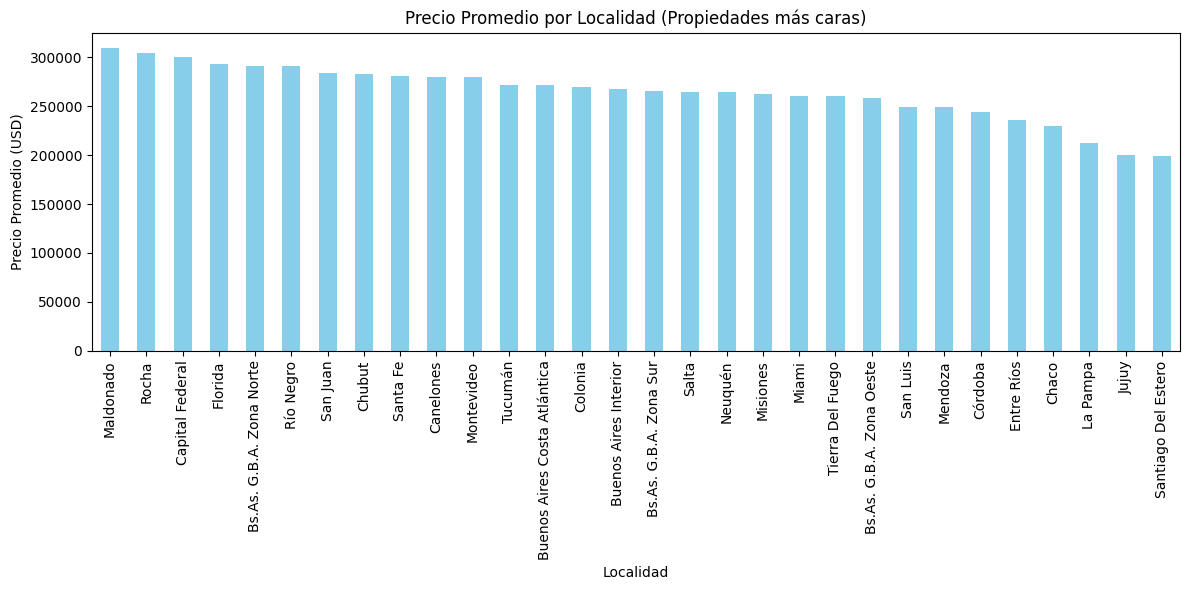

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
dataset_ventas_uss_caros_agrupados.plot(kind='bar', color='skyblue') # Added color here
plt.title('Precio Promedio por Localidad (Propiedades más caras)')
plt.xlabel('Localidad')
plt.ylabel('Precio Promedio (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# **Interpretación del gráfico:**

Este gráfico de barras muestra el precio promedio de las propiedades en USD para diferentes localidades, considerando únicamente las propiedades que se encuentran por encima del precio promedio general.

Podemos observar que hay una variación significativa en el precio promedio entre las distintas localidades. Algunas localidades como Maldonado, Rocha y Capital Federal tienen precios promedio más altos que otras, lo que podría indicar una mayor demanda o características especiales de las propiedades en esas áreas. Por otro lado, localidades como La Pampa, Jujuy y Santiago Del Estero presentan precios promedio más bajos dentro de este subconjunto de propiedades caras.

Este análisis sugiere que la ubicación es un factor muy importante en el precio de las propiedades, incluso dentro del rango de las propiedades de mayor valor.

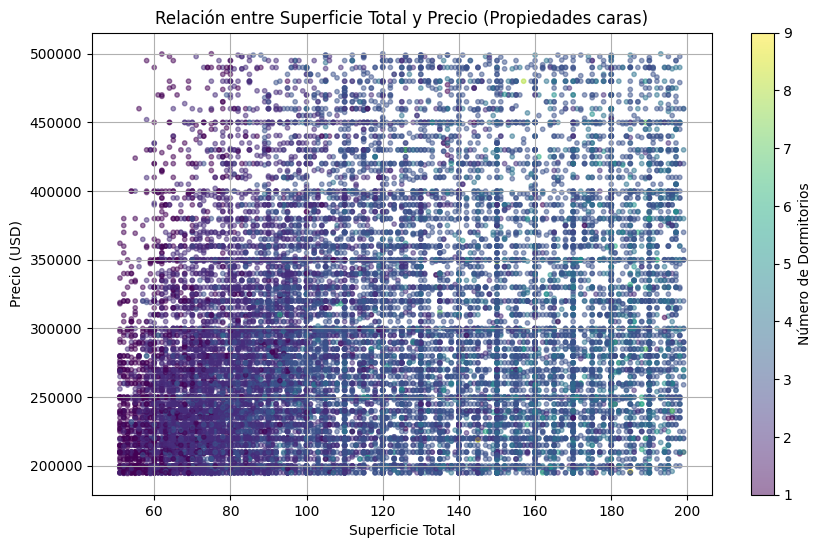

In [ ]:

plt.figure(figsize=(10, 6))
plt.scatter(dataset_ventas_uss_caros['Superficie_cubierta'], dataset_ventas_uss_caros['Precio'], alpha=0.5, s=10, c=dataset_ventas_uss_caros['Dormitorios'], cmap='viridis')
plt.title('Relación entre Superficie Total y Precio (Propiedades caras)')
plt.xlabel('Superficie Total')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.colorbar(label='Número de Dormitorios')
plt.show()


# **Interpretación del gráfico de dispersión:**

Este gráfico de dispersión muestra la relación entre la superficie total de las propiedades y su precio en USD, centrándose en las propiedades que superan el precio promedio general. Cada punto representa una propiedad, donde el eje X indica la superficie total, el eje Y indica el precio y el color del punto representa el número de dormitorios.

Observamos una tendencia general: a medida que aumenta la superficie total, el precio de la propiedad tiende a aumentar. Sin embargo, la relación no es perfectamente lineal, lo que sugiere que otros factores además de la superficie influyen en el precio. La dispersión de los puntos indica una variabilidad considerable en los precios para propiedades de tamaño similar.

Además, el uso del color para representar el número de dormitorios nos permite ver si hay alguna correlación entre el número de dormitorios y la relación superficie-precio. Puede haber agrupaciones de colores en ciertas áreas del gráfico, lo que indicaría que las propiedades con un número similar de dormitorios pueden tener tendencias de precio o superficie parecidas.

Es importante notar que existen algunos puntos atípicos con superficies muy grandes o precios excepcionalmente altos, que podrían requerir un análisis más detallado para entender su impacto en el mercado.

* SUB-PLOT COMPARATIVO ENTRE CAPITAL FEDERAL Y GRAN BUENOS AIRES

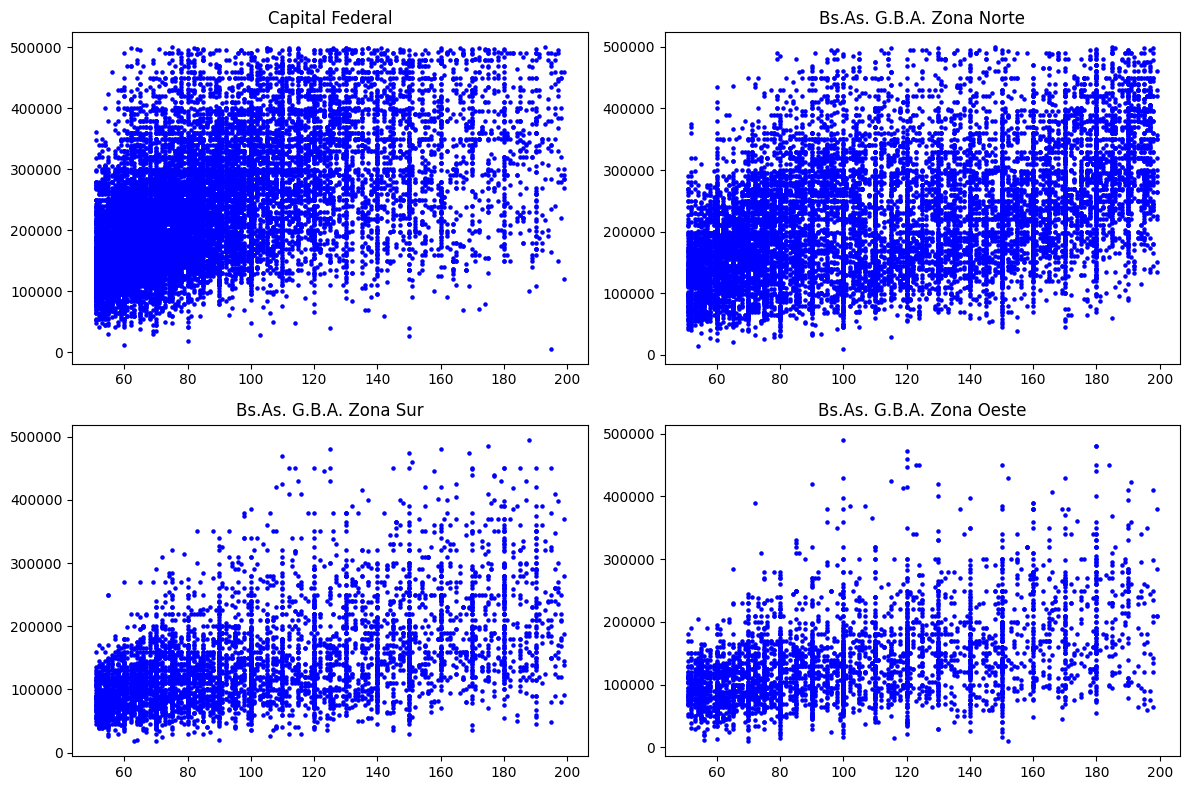

In [ ]:
dataset_caba =      dataset_ventas_uss[dataset_ventas_uss['Localidad']=='Capital Federal']
dataset_ba_norte =  dataset_ventas_uss[dataset_ventas_uss['Localidad']=='Bs.As. G.B.A. Zona Norte']
dataset_ba_sur =    dataset_ventas_uss[dataset_ventas_uss['Localidad']=='Bs.As. G.B.A. Zona Sur']
dataset_ba_oeste =  dataset_ventas_uss[dataset_ventas_uss['Localidad']=='Bs.As. G.B.A. Zona Oeste']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Usar cada espacio individualmente:
# Esquina superior izquierda [0,0]
axes[0, 0].scatter(dataset_caba['Superficie_cubierta'],dataset_caba['Precio'],color='blue', s=5)
axes[0, 0].set_title('Capital Federal')

# Esquina superior derecha [0,1]
axes[0, 1].scatter(dataset_ba_norte['Superficie_cubierta'],dataset_ba_norte['Precio'],color='blue', s=5)
axes[0, 1].set_title('Bs.As. G.B.A. Zona Norte')

# Esquina inferior izquierda [1,0]
axes[1, 0].scatter(dataset_ba_sur['Superficie_cubierta'],dataset_ba_sur['Precio'],color='blue', s=5)
axes[1, 0].set_title('Bs.As. G.B.A. Zona Sur')

# Esquina inferior derecha [1,1]
axes[1, 1].scatter(dataset_ba_oeste['Superficie_cubierta'],dataset_ba_oeste['Precio'],color='blue', s=5)
axes[1, 1].set_title('Bs.As. G.B.A. Zona Oeste')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

if 'dataset_ventas_uss_caros' in locals():
    print("El DataFrame 'dataset_ventas_uss_caros' existe.")

    required_columns = ['Precio', 'Superficie_cubierta', 'Dormitorios', 'Localidad', 'Tipo propiedad']
    missing_columns = [col for col in required_columns if col not in dataset_ventas_uss_caros.columns]

    if not missing_columns:
        print("Todas las columnas requeridas están presentes.")

        print("\nTipos de datos de las columnas requeridas:")
        print(dataset_ventas_uss_caros[required_columns].dtypes)

        if dataset_ventas_uss_caros['Precio'].dtype in ['float64', 'int64'] and \
           dataset_ventas_uss_caros['Superficie_cubierta'].dtype in ['float64', 'int64'] and \
           dataset_ventas_uss_caros['Dormitorios'].dtype in ['int64'] and \
           dataset_ventas_uss_caros['Localidad'].dtype == 'object' and \
           dataset_ventas_uss_caros['Tipo propiedad'].dtype == 'object':
            print("\nLos tipos de datos son adecuados para graficar.")
        else:
            print("\nLos tipos de datos podrían no ser adecuados para graficar.")
            # Posiblemente agregar código aquí para convertir tipos de datos si es necesario y posible
    else:
        print(f"Faltan las siguientes columnas requeridas: {missing_columns}")
else:
    print("El DataFrame 'dataset_ventas_uss_caros' no existe.")

El DataFrame 'dataset_ventas_uss_caros' existe.
Todas las columnas requeridas están presentes.

Tipos de datos de las columnas requeridas:
Precio                  Int64
Superficie_cubierta     Int64
Dormitorios             Int64
Localidad              object
Tipo propiedad         object
dtype: object

Los tipos de datos podrían no ser adecuados para graficar.


## Este código verifica la existencia del DataFrame `dataset_ventas_uss_caros` y confirma que contiene las columnas necesarias (`Precio`, `Superficie_cubierta`, `Dormitorios`, `Localidad`, `Tipo propiedad`) para realizar visualizaciones. Adicionalmente, comprueba que los tipos de datos de estas columnas sean adecuados para graficar, asegurando que los datos están en el formato correcto antes de generar gráficos y evitando posibles errores.

# **PARTE 4 | MACHINE LEARNING**

* CREACION DATASET PARA ENTRENAMIENTO (PROPIEDADES EXCLUSIVAMENTE EN **CIUDAD AUTONOMA DE BUENOS AIRES**)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

dataset_ventas_uss_caba=dataset_ventas_uss[dataset_ventas_uss['Localidad']=='Capital Federal'].sort_values(by=['Superficie_cubierta'], ascending=True)

df_entrenamiento = pd.DataFrame({'superficie': dataset_ventas_uss_caba['Superficie_cubierta'], 'precio': dataset_ventas_uss_caba['Precio']})
df_entrenamiento.head()

,superficie,precio
307349,51,137500
737905,51,139985
737904,51,142757
737812,51,209850
240,51,124500


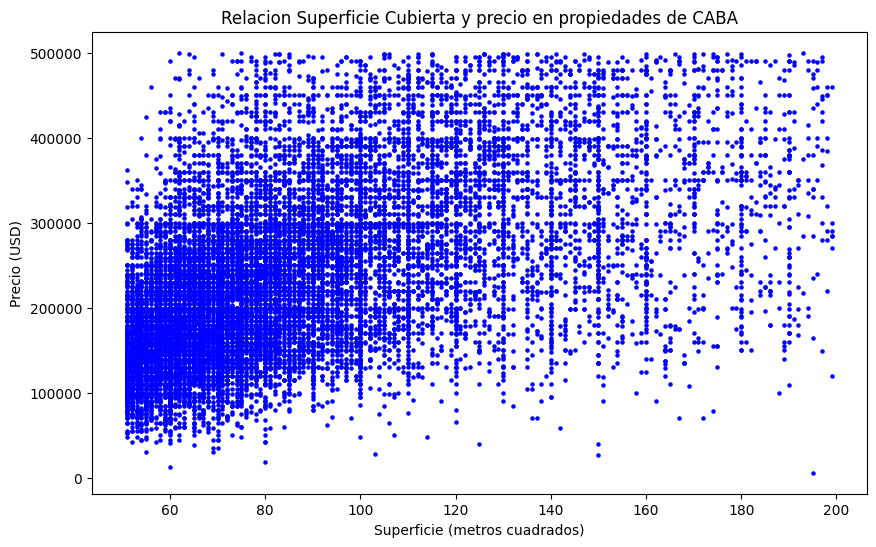

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_entrenamiento["superficie"], df_entrenamiento["precio"], color='blue', s=5, label='Datos reales')
plt.xlabel("Superficie (metros cuadrados)")
plt.ylabel("Precio (USD)")
plt.title("Relacion Superficie Cubierta y precio en propiedades de CABA")
plt.show()

* ENTRENAMIENTO MODELO

In [ ]:
X = df_entrenamiento[["superficie"]]
y = df_entrenamiento["precio"]
modelo = linear_model.LinearRegression()
modelo.fit(X, y)

LinearRegression()

* PREDICCIONES

In [ ]:
prediccion_una = modelo.predict([[50]])
prediccion_dos = modelo.predict([[110]])
prediccion_tres = modelo.predict([[190]])

print(f"Casa de 50 M²: Precio predicho = $ {prediccion_una[0]:.2f}")
print(f"Casa de 110 M²: Precio predicho = $ {prediccion_dos[0]:.2f}")
print(f"Casa de 190 M²: Precio predicho = $ {prediccion_dos[0]:.2f}")

Casa de 50 M²: Precio predicho = $ 177247.52
Casa de 110 M²: Precio predicho = $ 273656.02
Casa de 190 M²: Precio predicho = $ 273656.02


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


* VISUALIZACION LINEA DE REGRESION

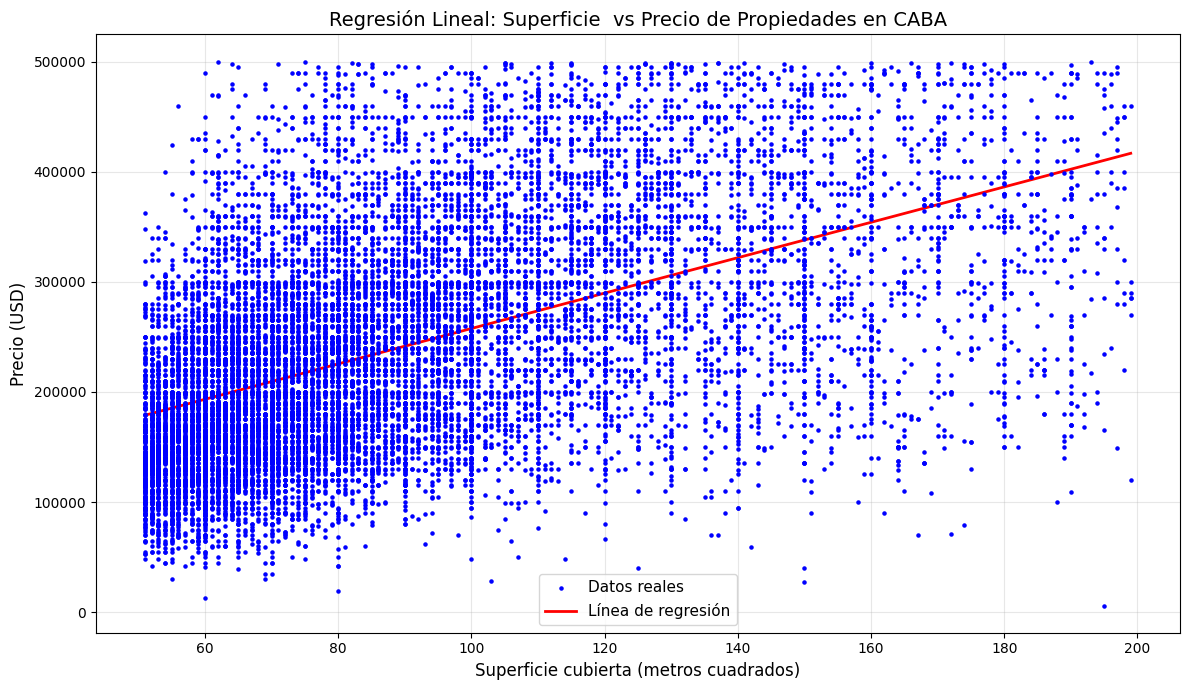

In [ ]:

predicciones_entrenamiento = modelo.predict(X)
plt.figure(figsize=(12, 7))


plt.scatter(df_entrenamiento["superficie"], df_entrenamiento["precio"], color='blue', s=5,
            label='Datos reales', zorder=5)


plt.plot(df_entrenamiento["superficie"], predicciones_entrenamiento, color='red',
         linewidth=2, label='Línea de regresión')


plt.xlabel("Superficie cubierta (metros cuadrados)", fontsize=12)
plt.ylabel("Precio (USD)", fontsize=12)
plt.title("Regresión Lineal: Superficie  vs Precio de Propiedades en CABA", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

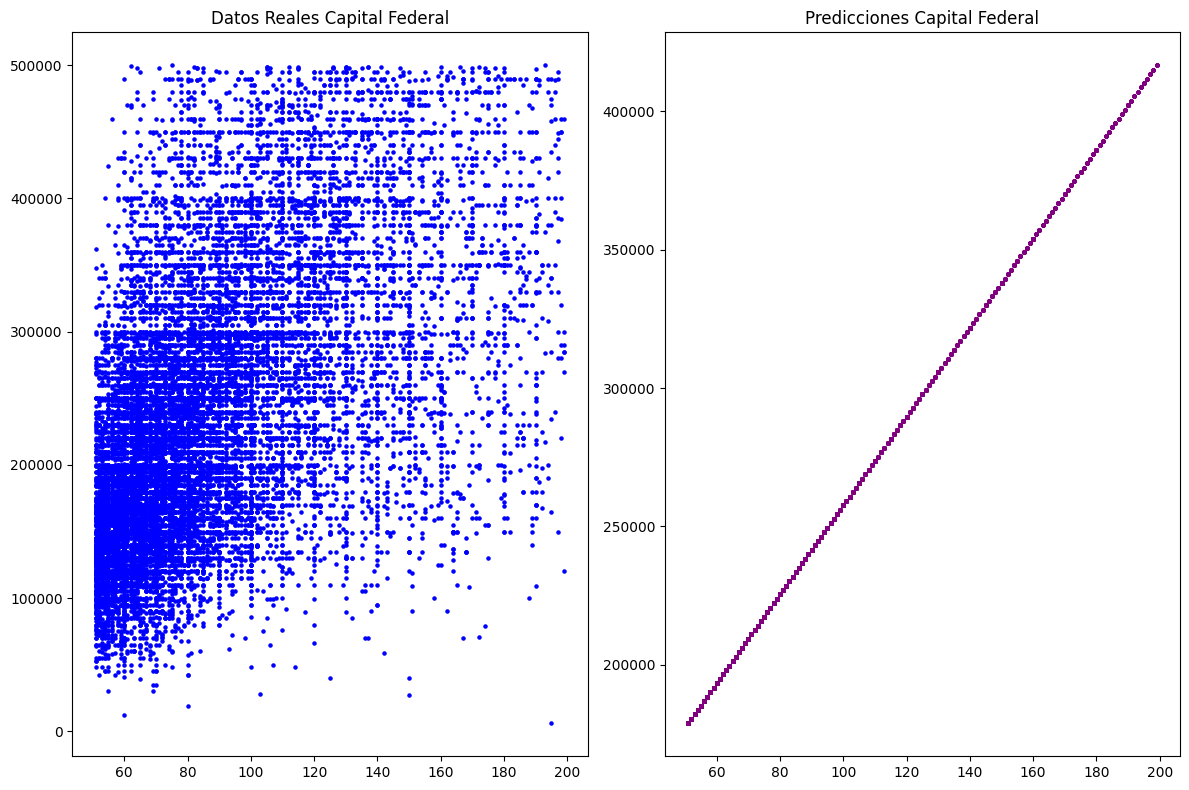

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))


axes[0].scatter(dataset_caba['Superficie_cubierta'],dataset_caba['Precio'],color='blue', s=5)
axes[0].set_title('Datos Reales Capital Federal')


axes[1].scatter(X,predicciones_entrenamiento,color='purple', s=5)
axes[1].set_title('Predicciones Capital Federal')

plt.tight_layout()
plt.show()

* EVALUACION DEL MODELO

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

predicciones = modelo.predict(X)
errores = y - predicciones

# Métrica 1: ¿Cuánto se equivoca el modelo?
error_promedio = np.mean(np.abs(errores))
print(f"Error promedio: ${error_promedio:,.2f}")
print(f"→ En promedio, el modelo se equivoca por esta cantidad")

# Métrica 2: Evaluación de calidad (0 a 1)
r2 = r2_score(y, predicciones)
print(f"\nCalificación del modelo (R²): {r2:.2f}")
if r2 >= 0.9:
    print(f"→ EXCELENTE: El modelo es muy bueno")
elif r2 >= 0.7:
    print(f"→ BUENO: El modelo funciona bien")
elif r2 >= 0.5:
    print(f"→ REGULAR: El modelo es aceptable")
else:
    print(f"→ MALO: El modelo necesita mejora")

Error promedio: $67,917.09
→ En promedio, el modelo se equivoca por esta cantidad

Calificación del modelo (R²): 0.27
→ MALO: El modelo necesita mejora


* EXAMINACION PARAMETROS

In [ ]:
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Ecuación que aprendió el modelo:")
print(f"Precio = {pendiente:.2f} × superficie + {intercepto:.2f}")
print()
print(f"- Por cada metro cuadrado el precio aumenta aproximadamente u$s{pendiente:,.0f}")


Ecuación que aprendió el modelo:
Precio = 1606.81 × superficie + 96907.10

- Por cada metro cuadrado el precio aumenta aproximadamente u$s1,607


* CALCULO ERROR CUADRÁTICO MEDIO (MSE) Y ERROR ABSOLUTO MEDIO (MAE)


In [ ]:
from sklearn.metrics import mean_absolute_error

mse = np.sqrt(mean_squared_error(y, predicciones))
print(f"\nError Cuadrático Medio (MSE): ${mse:,.2f}")

mae = mean_absolute_error(y, predicciones)
print(f"\nError Absoluto Medio (MAE): ${mae:,.2f}")



Error Cuadrático Medio (MSE): $85,391.71

Error Absoluto Medio (MAE): $67,917.09


# Conclusión
El objetivo del grupo fue construir un modelo simple que nos diera un referencia de precio a partir de una única variable determinante, la superficie de la propiedad.
Al llevar a cabo las pruebas, obtuvimos resultados que responden a una media logica y coherente. Sin embargo, con un alto margen de error por la dispersión existente en la base.

Al realizar la regresión lineal obtuvimos R² ≈ 0.27 y MAE ≈ USD 68k: no resuelve la variabilidad total, pero encuentra una tendencia de X: sube o baja los precios estimados de forma coherente, y mejora frente a predecir el promedio.

Hay mucha variación: para m² similares aparecen precios de 80k a 500k.
Con esa dispersión, la regresión lineal tiende al promedio cuando no hay suficiente información para distinguir casos.

Resultado: marca la tendencia, pero no captura toda la variación.

Como conclusión, el modelo cumple su función de marcar una tendencia y entregar un estimado razonable dentro de la dispersión del set.